Huidige map:/home/niels/BEP-Niels/Data Lobith)


Bestaat deze map? True
Pad: /home/niels/BEP-Niels/Data Lobith


Aantal Excelbestanden: 22
Data Lobith 1950-1953.xlsx
Data Lobith 1953-1956.xlsx
Data Lobith 1956-1959.xlsx
Data Lobith 1959-1962.xlsx
Data Lobith 1962-1965.xlsx
Data Lobith 1965-1968.xlsx
Data Lobith 1968-1971.xlsx
Data Lobith 1971-1974.xlsx
Data Lobith 1974-1977.xlsx
Data Lobith 1976-1979.xlsx
Data Lobith 1979-1982.xlsx
Data Lobith 1981-1984.xlsx
Data Lobith 1984-1987.xlsx
Data Lobith 1987-1990.xlsx
Data Lobith 1996-1997.xlsx
Data Lobith 1997-2000.xlsx
Data Lobith 2000-2003.xlsx
Data Lobith 2003-2006.xlsx
Data Lobith 2005-2008.xlsx
Data Lobith 2008-2011.xlsx
Data Lobith 2011-2014.xlsx
Data Lobith 2014-2017.xlsx


In [5]:
import pandas as pd
from pathlib import Path

# Map met je Excelbestanden
data_map = Path("/home/niels/BEP-Niels/Data Lobith")

# Outputbestand
output_file = data_map / "Lobith_afvoer_datetime_clean.xlsx"

# Alle Excelbestanden zoeken
excel_files = sorted([
    file for file in data_map.glob("*.xls*")
    if not file.name.startswith("~$")
    and "clean" not in file.name
    and "dagwaarden" not in file.name
])

print("Aantal bestanden gevonden:", len(excel_files))

all_data = []

for file in excel_files:
    print("Inlezen:", file.name)

    df = pd.read_excel(file)

    # Alleen relevante kolommen behouden
    df = df[[
        "WAARNEMINGDATUM",
        "WAARNEMINGTIJD",
        "NUMERIEKEWAARDE"
    ]].copy()

    # Datum omzetten
    df["WAARNEMINGDATUM"] = pd.to_datetime(
        df["WAARNEMINGDATUM"],
        errors="coerce"
    )

    # Datum en tijd samenvoegen
    df["datetime"] = pd.to_datetime(
        df["WAARNEMINGDATUM"].dt.strftime("%Y-%m-%d") + " " + df["WAARNEMINGTIJD"].astype(str),
        errors="coerce"
    )

    # Afvoerwaarde numeriek maken
    df["Q_m3s"] = pd.to_numeric(
        df["NUMERIEKEWAARDE"],
        errors="coerce"
    )

    # Alleen gewenste kolommen overhouden
    df = df[["datetime", "Q_m3s"]]

    # Foutieve of lege regels verwijderen
    df = df.dropna(subset=["datetime", "Q_m3s"])

    all_data.append(df)

# Alles samenvoegen
data_clean = pd.concat(all_data, ignore_index=True)

# Sorteren op datum/tijd
data_clean = data_clean.sort_values("datetime")

# Dubbele tijdstappen verwijderen vanwege overlappende bestanden
data_clean = data_clean.drop_duplicates(subset=["datetime"], keep="first")

# Exporteren
data_clean.to_excel(output_file, index=False)

print("\nKlaar.")
print("Opgeslagen als:", output_file)
print("Aantal regels:", len(data_clean))

print(data_clean.head())
print(data_clean.tail())

Aantal bestanden gevonden: 22
Inlezen: Data Lobith 1950-1953.xlsx
Inlezen: Data Lobith 1953-1956.xlsx
Inlezen: Data Lobith 1956-1959.xlsx
Inlezen: Data Lobith 1959-1962.xlsx
Inlezen: Data Lobith 1962-1965.xlsx
Inlezen: Data Lobith 1965-1968.xlsx
Inlezen: Data Lobith 1968-1971.xlsx
Inlezen: Data Lobith 1971-1974.xlsx
Inlezen: Data Lobith 1974-1977.xlsx
Inlezen: Data Lobith 1976-1979.xlsx
Inlezen: Data Lobith 1979-1982.xlsx
Inlezen: Data Lobith 1981-1984.xlsx
Inlezen: Data Lobith 1984-1987.xlsx
Inlezen: Data Lobith 1987-1990.xlsx
Inlezen: Data Lobith 1996-1997.xlsx
Inlezen: Data Lobith 1997-2000.xlsx
Inlezen: Data Lobith 2000-2003.xlsx
Inlezen: Data Lobith 2003-2006.xlsx
Inlezen: Data Lobith 2005-2008.xlsx
Inlezen: Data Lobith 2008-2011.xlsx
Inlezen: Data Lobith 2011-2014.xlsx
Inlezen: Data Lobith 2014-2017.xlsx

Klaar.
Opgeslagen als: /home/niels/BEP-Niels/Data Lobith/Lobith_afvoer_datetime_clean.xlsx
Aantal regels: 366665
             datetime   Q_m3s
0 1950-01-01 08:00:00  1425.0
1 19

In [6]:
# Zorg dat datetime echt als datetime wordt herkend
data_clean["datetime"] = pd.to_datetime(data_clean["datetime"], errors="coerce")

# Sorteer op tijd
data_clean = data_clean.sort_values("datetime")

# Daggemiddelde bepalen
daggemiddelden = (
    data_clean
    .set_index("datetime")
    .resample("D")["Q_m3s"]
    .mean()
    .reset_index()
)

# Kolommen netjes hernoemen
daggemiddelden = daggemiddelden.rename(columns={
    "datetime": "date",
    "Q_m3s": "Q_mean_m3s"
})

# Alleen de datum behouden, zonder tijdstip 00:00:00
daggemiddelden["date"] = daggemiddelden["date"].dt.date

# Eventuele dagen zonder waarde verwijderen
daggemiddelden = daggemiddelden.dropna(subset=["Q_mean_m3s"])

# Exporteren
output_daggemiddelden = data_map / "Lobith_daggemiddelden.xlsx"
daggemiddelden.to_excel(output_daggemiddelden, index=False)

print("Klaar.")
print("Opgeslagen als:", output_daggemiddelden)
print("Aantal dagen:", len(daggemiddelden))

print(daggemiddelden.head())
print(daggemiddelden.tail())

Klaar.
Opgeslagen als: /home/niels/BEP-Niels/Data Lobith/Lobith_daggemiddelden.xlsx
Aantal dagen: 21621
         date  Q_mean_m3s
0  1950-01-01      1425.0
1  1950-01-02      1360.0
2  1950-01-03      1330.0
3  1950-01-04      1320.0
4  1950-01-05      1330.0
             date    Q_mean_m3s
24469  2016-12-29  1.031420e+03
24470  2016-12-30  1.018468e+03
24471  2016-12-31  1.013862e+03
24472  2017-01-01  9.888300e+02
24473  2017-01-02  9.999990e+42


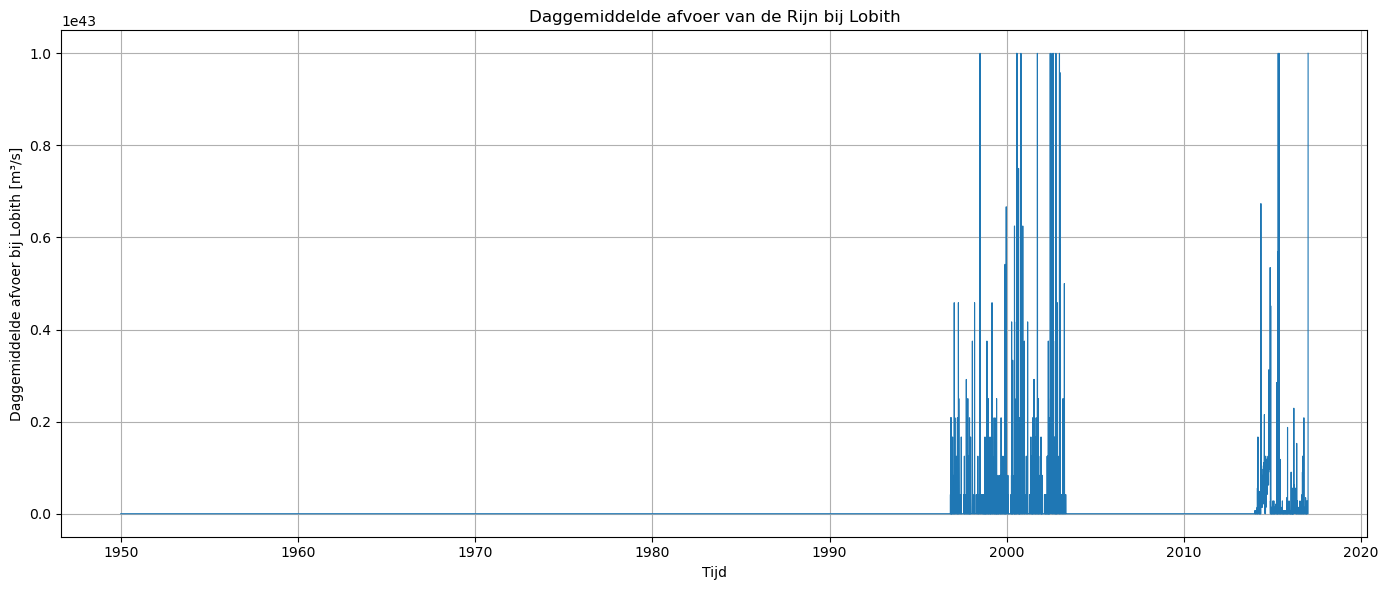

In [9]:
import matplotlib.pyplot as plt

# Zorg dat date als datetime wordt herkend
daggemiddelden["date"] = pd.to_datetime(daggemiddelden["date"], errors="coerce")

# Sorteer op datum
daggemiddelden = daggemiddelden.sort_values("date")

# Plot daggemiddelde afvoer tegen tijd
plt.figure(figsize=(14, 6))
plt.plot(daggemiddelden["date"], daggemiddelden["Q_mean_m3s"], linewidth=0.8)

plt.xlabel("Tijd")
plt.ylabel("Daggemiddelde afvoer bij Lobith [m³/s]")
plt.title("Daggemiddelde afvoer van de Rijn bij Lobith")
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Controleer de grootste waarden
print(data_clean["Q_m3s"].describe())

print("\nGrootste 20 waarden:")
print(
    data_clean
    .sort_values("Q_m3s", ascending=False)
    .head(20)
)

count    3.666650e+05
mean     1.802734e+41
std      1.330503e+42
min      6.650000e+02
25%      1.545430e+03
50%      1.998260e+03
75%      2.676550e+03
max      9.999990e+42
Name: Q_m3s, dtype: float64

Grootste 20 waarden:
                  datetime         Q_m3s
376607 2017-01-02 00:00:00  9.999990e+42
256103 2014-09-19 04:00:00  9.999990e+42
255998 2014-09-18 10:30:00  9.999990e+42
256012 2014-09-18 12:50:00  9.999990e+42
256035 2014-09-18 16:40:00  9.999990e+42
256040 2014-09-18 17:30:00  9.999990e+42
256053 2014-09-18 19:40:00  9.999990e+42
256070 2014-09-18 22:30:00  9.999990e+42
256071 2014-09-18 22:40:00  9.999990e+42
256073 2014-09-18 23:00:00  9.999990e+42
256077 2014-09-18 23:40:00  9.999990e+42
256114 2014-09-19 05:50:00  9.999990e+42
255982 2014-09-18 07:50:00  9.999990e+42
256122 2014-09-19 07:10:00  9.999990e+42
256136 2014-09-19 09:30:00  9.999990e+42
256162 2014-09-19 13:50:00  9.999990e+42
256176 2014-09-19 16:10:00  9.999990e+42
256178 2014-09-19 16:30:00  9.999990

In [11]:
# Alleen fysisch realistische afvoerwaarden behouden
data_clean_filtered = data_clean[
    (data_clean["Q_m3s"] > 0) &
    (data_clean["Q_m3s"] < 20000)
].copy()

print("Aantal waarden vóór filtering:", len(data_clean))
print("Aantal waarden na filtering:", len(data_clean_filtered))
print("Aantal verwijderde waarden:", len(data_clean) - len(data_clean_filtered))

Aantal waarden vóór filtering: 366665
Aantal waarden na filtering: 360055
Aantal verwijderde waarden: 6610


In [15]:
daggemiddelden = (
    data_clean_filtered
    .set_index("datetime")
    .resample("D")["Q_m3s"]
    .agg(
        Q_mean_m3s="mean",
        Q_min_m3s="min",
        Q_max_m3s="max",
        n_measurements="count"
    )
    .reset_index()
)

daggemiddelden = daggemiddelden.rename(columns={"datetime": "date"})
daggemiddelden = daggemiddelden.dropna(subset=["Q_mean_m3s"])

print(daggemiddelden.head())
print(daggemiddelden.tail())

        date  Q_mean_m3s  Q_min_m3s  Q_max_m3s  n_measurements
0 1950-01-01      1425.0     1425.0     1425.0               1
1 1950-01-02      1360.0     1360.0     1360.0               1
2 1950-01-03      1330.0     1330.0     1330.0               1
3 1950-01-04      1320.0     1320.0     1320.0               1
4 1950-01-05      1330.0     1330.0     1330.0               1
            date   Q_mean_m3s  Q_min_m3s  Q_max_m3s  n_measurements
24468 2016-12-28  1039.407639    1022.56    1058.83             144
24469 2016-12-29  1031.420139    1010.61    1054.82             144
24470 2016-12-30  1018.467569    1002.67    1039.56             144
24471 2016-12-31  1013.862083     994.77    1034.80             144
24472 2017-01-01   988.830000     949.49    1010.93             144


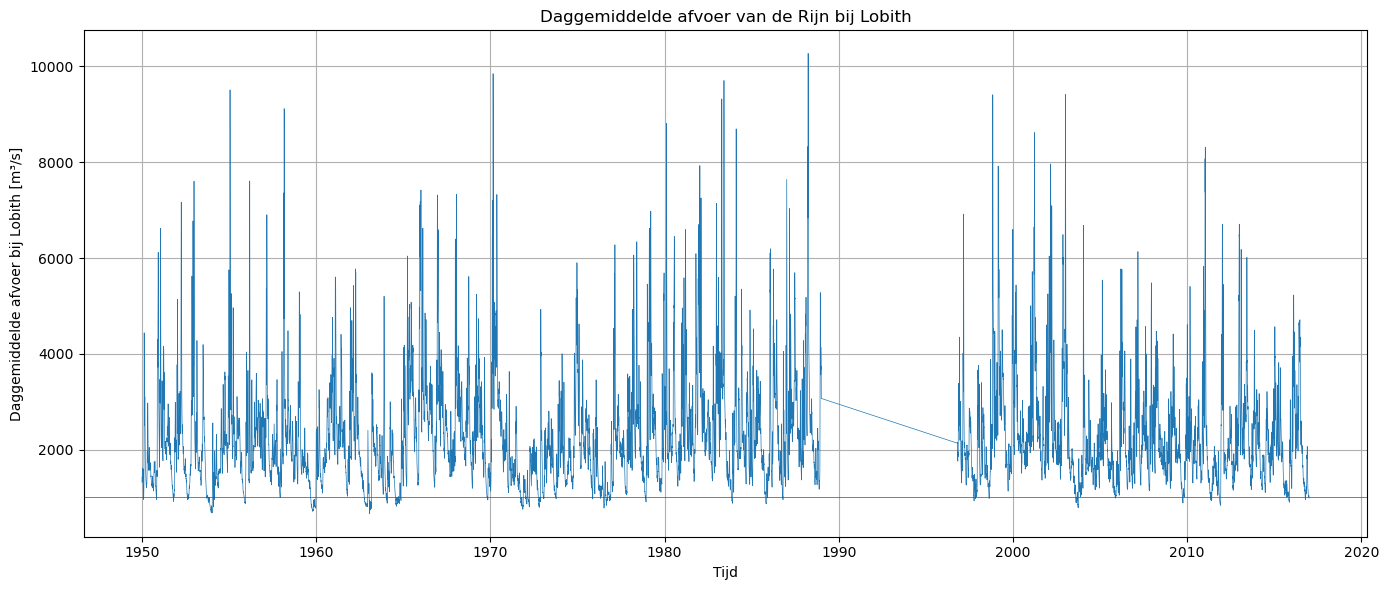

In [29]:

plt.figure(figsize=(14, 6))
plt.plot(daggemiddelden["date"], daggemiddelden["Q_mean_m3s"], linewidth=0.5)
plt.xlabel("Tijd")
plt.ylabel("Daggemiddelde afvoer bij Lobith [m³/s]")
plt.title("Daggemiddelde afvoer van de Rijn bij Lobith")
plt.grid(True)
plt.axhline(1020, color='r', linewidth=0.5)

plt.tight_layout()
plt.show()

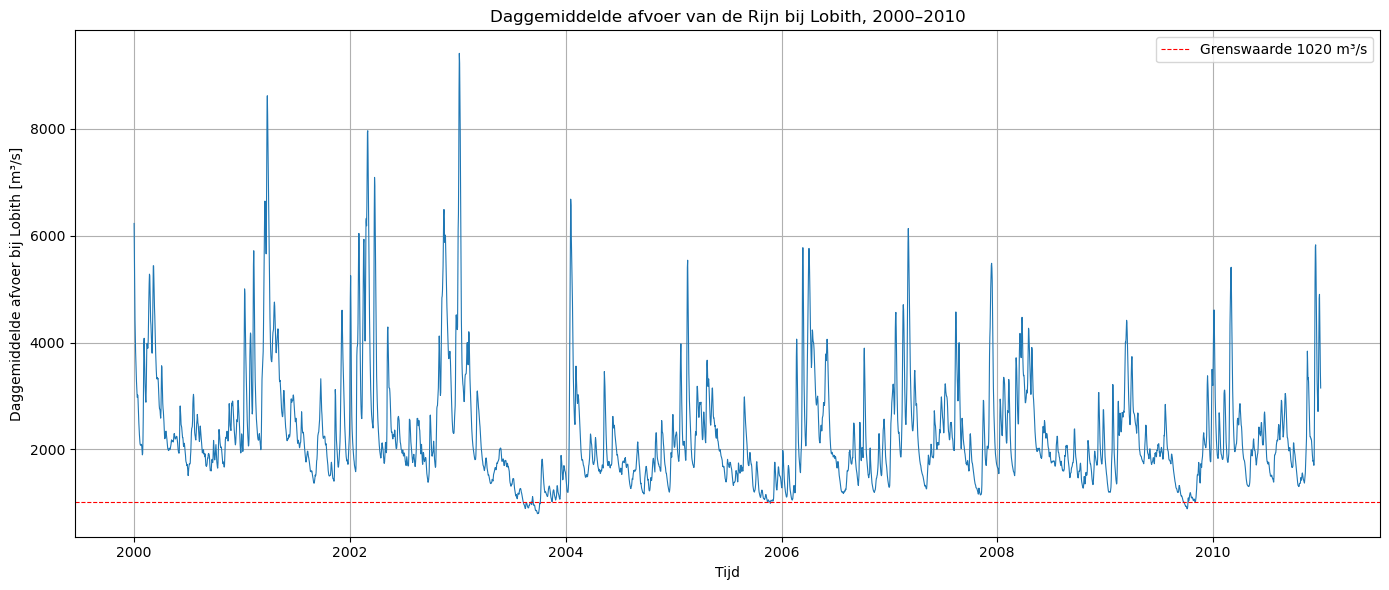

Aantal dagen in selectie: 4005
            date   Q_mean_m3s  Q_min_m3s  Q_max_m3s  n_measurements
18262 2000-01-01  6229.970833     5984.8     6426.0              24
18263 2000-01-02  5621.308333     5279.8     5971.9              24
18264 2000-01-03  4954.066667     4682.4     5256.4              24
18265 2000-01-04  4429.220833     4253.8     4660.0              24
18266 2000-01-05  4094.550000     3959.8     4234.2              24
            date   Q_mean_m3s  Q_min_m3s  Q_max_m3s  n_measurements
22275 2010-12-27  4903.125000     4705.0     4983.0              24
22276 2010-12-28  4409.291667     4129.0     4683.0              24
22277 2010-12-29  3877.833333     3642.0     4109.0              24
22278 2010-12-30  3443.833333     3285.0     3624.0              24
22279 2010-12-31  3149.083333     3020.0     3285.0              24


In [27]:
# Zorg dat de datumkolom als datetime wordt herkend
daggemiddelden["date"] = pd.to_datetime(daggemiddelden["date"], errors="coerce")

# Selecteer de periode 2000 t/m 2010
periode_2000_2010 = daggemiddelden[
    (daggemiddelden["date"] >= "2000-01-01") &
    (daggemiddelden["date"] <= "2010-12-31")
].copy()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(
    periode_2000_2010["date"],
    periode_2000_2010["Q_mean_m3s"],
    linewidth=0.8
)




# Eventuele grenswaarde voor bevaarbaarheid/laagwater
plt.axhline(1020, color="r", linewidth=0.8, linestyle="--", label="Grenswaarde 1020 m³/s")

plt.xlabel("Tijd")
plt.ylabel("Daggemiddelde afvoer bij Lobith [m³/s]")
plt.title("Daggemiddelde afvoer van de Rijn bij Lobith, 2000–2010")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Aantal dagen in selectie:", len(periode_2000_2010))
print(periode_2000_2010.head())
print(periode_2000_2010.tail())